In [1]:
import numpy as np

# The same GPT-2 output distribution p(w | "Hello world, nice to") from above, top 10 of 50257 words
tokens = ["see", "meet", "hear", "have", "be", "know", "you", "talk", "say", "get"]
probs = np.array([0.3169, 0.1268, 0.1246, 0.1046, 0.0471, 0.0352, 0.0320, 0.0128, 0.0114, 0.0067])

print("Asking GPT-2 what is p(w|Hello world, nice to):")
for i in np.argsort(-probs):
    print(f"{tokens[i]} : {probs[i]:.4f}")
print(f"Total sum of p(w|Hello world, nice to): {probs.sum():.4f}")

Asking GPT-2 what is p(w|Hello world, nice to):
see : 0.3169
meet : 0.1268
hear : 0.1246
have : 0.1046
be : 0.0471
know : 0.0352
you : 0.0320
talk : 0.0128
say : 0.0114
get : 0.0067
Total sum of p(w|Hello world, nice to): 0.8181


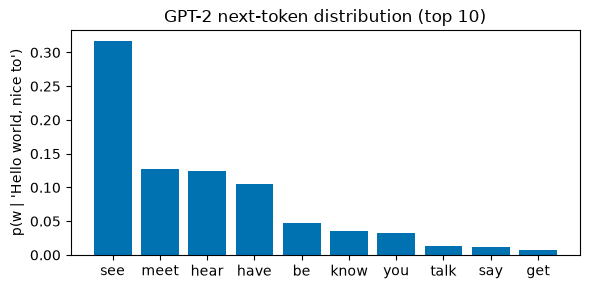

In [2]:
import matplotlib.pyplot as plt

order = np.argsort(-probs)
plt.figure(figsize=(6, 3))
plt.bar([tokens[i] for i in order], probs[order], color="#0072B2")
plt.ylabel("p(w | 'Hello world, nice to')")
plt.title("GPT-2 next-token distribution (top 10)")
plt.tight_layout()
plt.show()

In [3]:
rng = np.random.default_rng()

n = 10_000_000
target_e = "see"

# p must normalize to 1, so we renormalize our top-10 slice of the distribution
p = probs / probs.sum()
# draw all n samples at once, according to p(w | "Hello world, nice to")
outcomes = rng.choice(tokens, size=n, p=p)

prob_e = p[tokens.index(target_e)]
freq_e = np.mean(outcomes == target_e)
print(f"the expected probability of \"{target_e}\" is {prob_e}")
print(f"the actual frequency of \"{target_e}\" in {n} trials is {freq_e}")

the expected probability of "see" is 0.387360958318054
the actual frequency of "see" in 10000000 trials is 0.3873715


In [3]:
print("gpt-2's output distribution is stored with an np.ndarray rather than a vanilla python list")
print(f"probs.shape {type(probs.shape)}: {probs.shape}")
print(f"probs.dtype {type(probs.dtype)}: {probs.dtype}")

gpt-2's output distribution is stored with an np.ndarray rather than a vanilla python list
probs.shape <class 'tuple'>: (10,)
probs.dtype <class 'numpy.dtypes.Float64DType'>: float64
